<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/bioassay/bioassay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bioassay: Bayesian workflow

**Short Bayesian course — worked example**

$$
\text{data}
\rightarrow
\text{model}
\rightarrow
\text{prior predictive}
\rightarrow
\text{fit}
\rightarrow
LD50
\rightarrow
\text{posterior predictive}
$$

## 0. Setup

This course pins PyMC, modular ArviZ, and Bambi for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1" \
    "bambi==0.21.0"

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260923
azp.style.use("arviz-variat")

# Figures used in the slides: Slides/figures/<notebook>_<section>[_<n>].svg
NOTEBOOK = "bioassay"
FIG_DIR = Path("../Slides/figures") if Path("../Slides").is_dir() else Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_slide_figure(fig, section, number=None):
    """Save a Matplotlib figure or ArviZ PlotCollection for the slides."""
    suffix = f"_{number}" if number else ""
    fig.savefig(
        FIG_DIR / f"{NOTEBOOK}_{section}{suffix}.svg", bbox_inches="tight", transparent=True
    )

DRAW_COLOR = "#12505e"  # darker shade of the band colour C0

def plot_curve_draws(ax, x, curves):
    """Thin lines for individual draws of the dose-response curve."""
    ax.plot(x, curves, color=DRAW_COLOR, lw=0.8, alpha=0.55, zorder=1.5)

def plot_simulated_datasets(ax, x, datasets):
    """Dots for simulated counts, nudged sideways so repeated counts stay visible."""
    jitter = np.random.default_rng(RANDOM_SEED).uniform(-0.05, 0.05, datasets.shape)
    ax.set_autoscale_on(False)  # keep the same dose axis as the other plots
    ax.scatter(
        np.asarray(x)[:, None] + jitter,
        datasets,
        s=14,
        color=DRAW_COLOR,
        alpha=0.8,
        edgecolors="white",
        linewidths=0.4,
        zorder=1.5,
    )

def add_interval_legend(ax, line_label="mean", draws_label="20 draws", draws_as_points=False):
    """Compact one-row legend above the plot, so it never hides draws or data."""
    if draws_as_points:
        draws_handle = Line2D(
            [0], [0], marker="o", linestyle="none", color=DRAW_COLOR,
            markersize=4, label=draws_label,
        )
    else:
        draws_handle = Line2D([0], [0], color=DRAW_COLOR, lw=0.9, label=draws_label)
    ax.legend(
        handles=[
            Line2D([0], [0], color="C1", lw=1.6, label=line_label),
            Patch(facecolor="C0", alpha=0.9, label="50% HDI"),
            Patch(facecolor="C0", alpha=0.28, label="90% HDI"),
            draws_handle,
            Line2D(
                [0], [0], marker="o", linestyle="none", color="black",
                markersize=4.5, label="observed",
            ),
        ],
        loc="lower left",
        bbox_to_anchor=(0, 1.01),
        ncols=5,
        fontsize=8,
        handlelength=1.4,
        handletextpad=0.45,
        columnspacing=0.9,
        borderaxespad=0,
        frameon=False,
    )

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## 1. Data

In [3]:
dose = np.array([-0.86, -0.30, -0.05, 0.73])
n = np.array([5, 5, 5, 5])
deaths = np.array([0, 1, 3, 5])

bioassay = pd.DataFrame(
    {
        "dose_log_g_ml": dose,
        "animals": n,
        "deaths": deaths,
    }
)
bioassay["proportion_dead"] = bioassay["deaths"] / bioassay["animals"]
bioassay

,dose_log_g_ml,animals,deaths,proportion_dead
0,-0.86,5,0,0.0
1,-0.30,5,1,0.2
2,-0.05,5,3,0.6
3,0.73,5,5,1.0


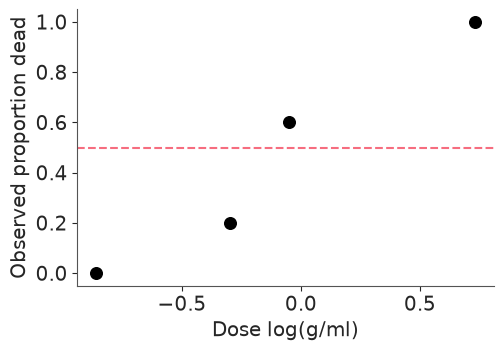

In [4]:
fig, ax = plt.subplots(figsize=(5, 3.4))
ax.scatter(dose, deaths / n, s=70, color="black")
ax.set(
    xlabel="Dose log(g/ml)",
    ylabel="Observed proportion dead",
    ylim=(-0.05, 1.05),
)
save_slide_figure(fig, "data")

# LD50 is the dose at which the probability of death crosses 50%.
ax.axhline(0.5, color="C1", linestyle="--")
save_slide_figure(fig, "data", 2)
plt.show()

## 2. Model

$$
y_j\sim\operatorname{Binomial}(n_j,p_j),
\qquad
\operatorname{logit}(p_j)=\alpha+\beta x_j
$$

$$
\alpha\sim N(0,5),
\qquad
\beta\sim\operatorname{HalfNormal}(5).
$$

In [5]:
coords = {"dose_log_g_ml": dose}

with pm.Model(coords=coords) as model:
    dose_data = pm.Data("dose", dose, dims="dose_log_g_ml")

    alpha = pm.Normal("alpha", mu=0, sigma=5)
    beta = pm.HalfNormal("beta", sigma=5)

    logit_p = alpha + beta * dose_data
    p = pm.Deterministic(
        "p",
        pm.math.sigmoid(logit_p),
        dims="dose_log_g_ml",
    )

    ld50_log_g_ml = pm.Deterministic(
        "LD50_log_g_ml",
        -alpha / beta,
    )
    ld50_mg_ml = pm.Deterministic(
        "LD50_mg_ml",
        1000 * pm.math.exp(ld50_log_g_ml),
    )

    pm.Binomial(
        "deaths",
        n=n,
        logit_p=logit_p,
        observed=deaths,
        dims="dose_log_g_ml",
    )

## 3. Prior predictive

**Question:** Before fitting, what death counts do these priors say are plausible?

These intervals summarize replicated **death counts** $y$. Because $y$ is discrete and often skewed, the mean need not sit in the middle of an HDI. Dose is continuous, so the bands run across dose even though only four doses were tested. The dark dots are 20 of the simulated datasets, nudged sideways so repeated counts stay visible.

In [6]:
with model:
    prior = pm.sample_prior_predictive(
        draws=1000,
        var_names=["alpha", "beta", "p", "deaths"],
        random_seed=RANDOM_SEED,
    )

Sampling: [alpha, beta, deaths]


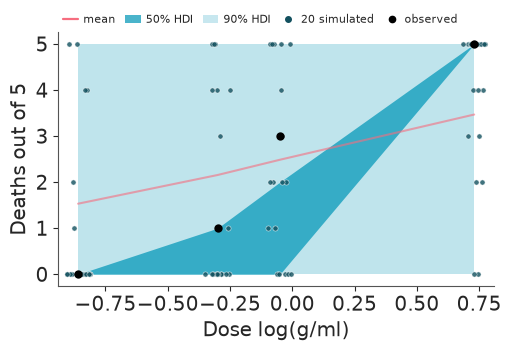

In [7]:
prior_datasets = azb.extract(
    prior,
    group="prior_predictive",
    var_names="deaths",
    num_samples=20,
    random_seed=RANDOM_SEED,
)

azp.plot_lm(
    prior,
    x="dose",
    y="deaths",
    y_obs="deaths",
    group="prior_predictive",
    plot_dim="dose_log_g_ml",
    ci_prob=(0.50, 0.90),
    ci_kind="hdi",
    point_estimate="mean",
    smooth=False,
    figure_kwargs={"figsize": (5, 3.4)},
    visuals={
        "pe_line": {"color": "C1"},
        "ci_band": {"color": "C0"},
        "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3},
    },
)

ax = plt.gca()
plot_simulated_datasets(ax, dose, prior_datasets)
ax.set(xlabel="Dose log(g/ml)", ylabel="Deaths out of 5", ylim=(-0.25, 5.25))
add_interval_legend(ax, line_label="mean", draws_label="20 simulated", draws_as_points=True)
save_slide_figure(plt.gcf(), "prior-predictive")
plt.show()

## 4. Fit and diagnose

In [8]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        nuts={"target_accept": 0.90},
        random_seed=RANDOM_SEED,
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, beta]


d:\Repositories\BayesShortCourse\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 20 seconds.


In [9]:
print("Divergences:", idata["sample_stats"]["diverging"].sum().item())

azs.summary(
    idata,
    var_names=["alpha", "beta"],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.58,0.78,-0.68,1.85,1812.97,1360.60,1.0,0.02,0.02
beta,6.30,2.55,1.99,10.10,1594.77,1745.46,1.0,0.06,0.04


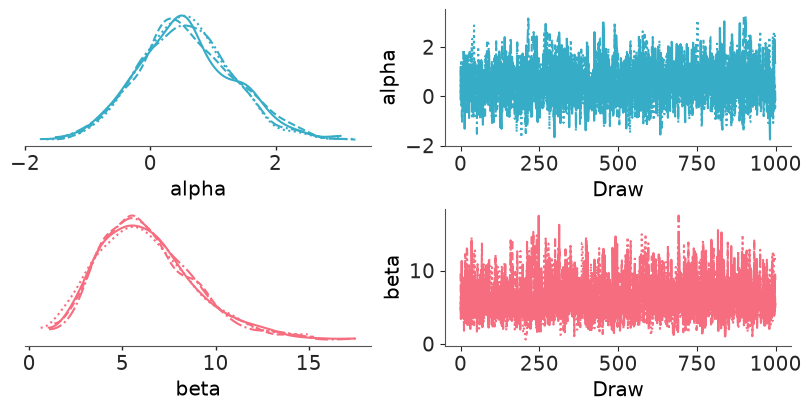

In [10]:
pc = azp.plot_trace_dist(
    idata,
    var_names=["alpha", "beta"],
    figure_kwargs={"figsize": (8, 4)},
)
save_slide_figure(pc, "fit-and-diagnose")

## 5. Posterior dose-response fit

This plot shows uncertainty about the underlying mean response, $5p$. The thin lines are 20 posterior draws of that curve. The 50% and 90% HDIs are intervals for the fitted dose-response relationship; they do **not** yet include the extra Binomial variation in a new group of five animals.

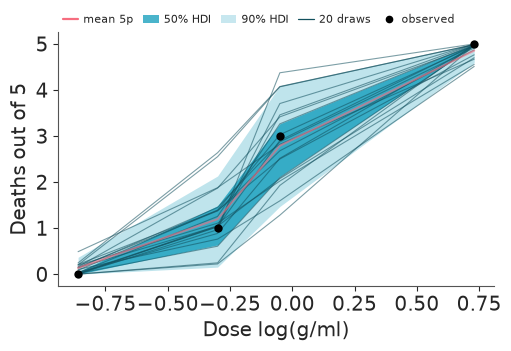

In [11]:
idata["posterior"]["expected_deaths"] = 5 * idata["posterior"]["p"]
posterior_curves = azb.extract(
    idata,
    group="posterior",
    var_names="expected_deaths",
    num_samples=20,
    random_seed=RANDOM_SEED,
)

azp.plot_lm(
    idata,
    x="dose",
    y="expected_deaths",
    y_obs="deaths",
    group="posterior",
    plot_dim="dose_log_g_ml",
    ci_prob=(0.50, 0.90),
    ci_kind="hdi",
    point_estimate="mean",
    smooth=False,
    figure_kwargs={"figsize": (5, 3.4)},
    visuals={
        "pe_line": {"color": "C1"},
        "ci_band": {"color": "C0"},
        "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3},
    },
)

ax = plt.gca()
plot_curve_draws(ax, dose, posterior_curves)
ax.set(xlabel="Dose log(g/ml)", ylabel="Deaths out of 5", ylim=(-0.25, 5.25))
add_interval_legend(ax, line_label="mean 5p", draws_label="20 draws")
save_slide_figure(plt.gcf(), "posterior-dose-response-fit")
plt.show()

For comparison, the same plot before seeing the data: the dose-response curves the prior allows.

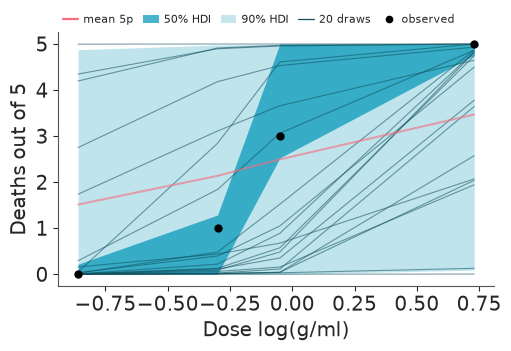

In [12]:
prior["prior"]["expected_deaths"] = 5 * prior["prior"]["p"]
prior_curves = azb.extract(
    prior,
    group="prior",
    var_names="expected_deaths",
    num_samples=20,
    random_seed=RANDOM_SEED,
)

azp.plot_lm(
    prior,
    x="dose",
    y="expected_deaths",
    y_obs="deaths",
    group="prior",
    plot_dim="dose_log_g_ml",
    ci_prob=(0.50, 0.90),
    ci_kind="hdi",
    point_estimate="mean",
    smooth=False,
    figure_kwargs={"figsize": (5, 3.4)},
    visuals={
        "pe_line": {"color": "C1"},
        "ci_band": {"color": "C0"},
        "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3},
    },
)

ax = plt.gca()
plot_curve_draws(ax, dose, prior_curves)
ax.set(xlabel="Dose log(g/ml)", ylabel="Deaths out of 5", ylim=(-0.25, 5.25))
add_interval_legend(ax, line_label="mean 5p", draws_label="20 draws")
save_slide_figure(plt.gcf(), "posterior-dose-response-fit", 2)
plt.show()

## 6. LD50

$$
LD50=-\frac{\alpha}{\beta}.
$$

It is stored as a PyMC deterministic quantity.

In [13]:
azs.summary(
    idata,
    var_names=["LD50_log_g_ml", "LD50_mg_ml"],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
LD50_log_g_ml,-0.08,0.14,-0.29,0.15,2603.34,2225.1,1.0,0.00,0.0
LD50_mg_ml,930.30,134.16,715.54,1119.34,2603.34,2225.1,1.0,2.61,4.3


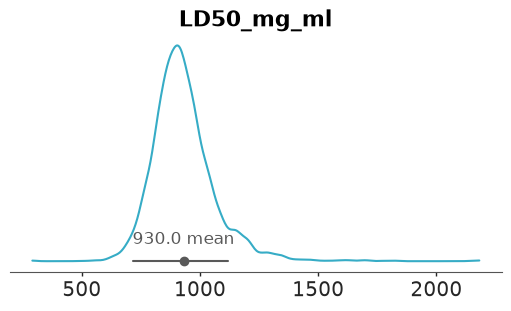

In [14]:
pc = azp.plot_dist(
    idata,
    var_names=["LD50_mg_ml"],
    point_estimate="mean",
    ci_prob=0.90,
    ci_kind="hdi",
    figure_kwargs={"figsize": (5, 3)},
)
save_slide_figure(pc, "ld50")

## 7. Posterior predictive

**Question:** After fitting, can the model generate death counts like those observed?

This uses the same display as the prior predictive check, but now the replicated counts are conditioned on the data. Unlike the posterior dose-response plot above, these intervals are for $y$, so they include both uncertainty about $p$ and Binomial outcome variability. Each of the 20 simulated datasets comes from one of the 20 curves drawn in section 5.

In [15]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["deaths"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

Sampling: [deaths]


d:\Repositories\BayesShortCourse\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

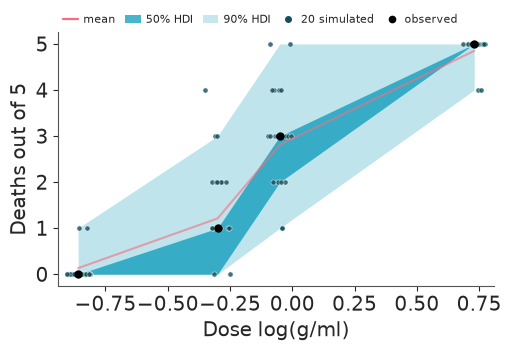

In [16]:
# Same seed and number of draws as the curves in section 5: dataset i comes from curve i.
posterior_datasets = azb.extract(
    idata,
    group="posterior_predictive",
    var_names="deaths",
    num_samples=20,
    random_seed=RANDOM_SEED,
)

azp.plot_lm(
    idata,
    x="dose",
    y="deaths",
    y_obs="deaths",
    group="posterior_predictive",
    plot_dim="dose_log_g_ml",
    ci_prob=(0.50, 0.90),
    ci_kind="hdi",
    point_estimate="mean",
    smooth=False,
    figure_kwargs={"figsize": (5, 3.4)},
    visuals={
        "pe_line": {"color": "C1"},
        "ci_band": {"color": "C0"},
        "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3},
    },
)

ax = plt.gca()
plot_simulated_datasets(ax, dose, posterior_datasets)
ax.set(xlabel="Dose log(g/ml)", ylabel="Deaths out of 5", ylim=(-0.25, 5.25))
add_interval_legend(ax, line_label="mean", draws_label="20 simulated", draws_as_points=True)
save_slide_figure(plt.gcf(), "posterior-predictive")
plt.show()

## 8. Bambi

**Question:** Can we fit the same model with less code?

Bambi builds PyMC models from a regression formula. `p(deaths, n)` means deaths out of `n` trials, `family="binomial"` uses the logit link, and the priors match the PyMC model above. Bambi is included in the pinned setup above because it is not preinstalled in Colab.

In [17]:
import bambi as bmb

print("Bambi:", bmb.__version__)

bambi_data = pd.DataFrame({"dose": dose, "n": n, "deaths": deaths})

bambi_model = bmb.Model(
    "p(deaths, n) ~ dose",
    bambi_data,
    family="binomial",
    priors={
        "Intercept": bmb.Prior("Normal", mu=0, sigma=5),
        "dose": bmb.Prior("HalfNormal", sigma=5),
    },
)
bambi_idata = bambi_model.fit(chains=4, random_seed=RANDOM_SEED)

azs.summary(
    bambi_idata,
    var_names=["Intercept", "dose"],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

Bambi: 0.21.0


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [Intercept, dose]


d:\Repositories\BayesShortCourse\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 18 seconds.


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.59,0.8,-0.7,1.93,2676.36,2134.11,1.0,0.02,0.02
dose,6.37,2.6,2.4,10.67,2228.66,2005.96,1.0,0.05,0.04


The intercept and slope match $\alpha$ and $\beta$ from the PyMC fit. Bambi's plot shows the mean probability of death across a fine grid of doses, with its 90% HDI.

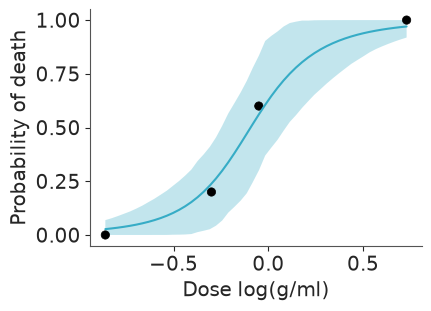

In [18]:
import warnings
import seaborn.objects as so

# Bambi 0.21 returns a seaborn Plot here; later versions will return a Matplotlib figure.
warnings.filterwarnings("ignore", category=bmb.PlottingFutureWarning)

fig = plt.figure(figsize=(4.2, 3))
(
    bmb.interpret.plot_predictions(bambi_model, bambi_idata, "dose", prob=0.90)
    .add(
        so.Dot(color="black"),
        data=bambi_data.assign(proportion=deaths / n),
        x="dose",
        y="proportion",
    )
    .label(x="Dose log(g/ml)", y="Probability of death")
    .theme(plt.rcParams)  # match the notebook's ArviZ style
    .on(fig)
    .plot()
)
save_slide_figure(fig, "bambi")
plt.show()

## Explore

- Remove the positive-slope constraint.
- Change the priors and rerun the prior predictive check.

Source: Gelman & Vehtari, *Bayesian Workflow*, §3.5.